In [15]:
import numpy as np
import pandas
import zipfile
import src.file
from src.file import example
import os
import tensorflow as tf
from tensorflow import keras as keras
from tensorflow.keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

In [24]:
zip_path = "HARIS.zip"
extract_path = "data/HARIS/"

# Make sure the destination folder exists
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [17]:
import shutil

HARIS_image_dir = "data/HARIS/HARIS_Weapon_Detection_Dataset_v2/HARIS_Weapon_Detection_Dataset/train/images"
HARIS_label_dir = "data/HARIS/HARIS_Weapon_Detection_Dataset_v2/HARIS_Weapon_Detection_Dataset/train/labels"

output_weapon = "data/HARIS_classification_train/weapon"
output_no_weapon = "data/HARIS_classification_train/no_weapon"

os.makedirs(output_weapon, exist_ok=True)
os.makedirs(output_no_weapon, exist_ok=True)

for img_file in os.listdir(HARIS_image_dir):
    if not img_file.endswith(".jpg"):
        continue

    base_name = os.path.splitext(img_file)[0]
    label_file = os.path.join(HARIS_label_dir, base_name + ".txt")
    img_path = os.path.join(HARIS_image_dir, img_file)

    # Case 1: label file exists
    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            content = f.read().strip()

        if content:  # has coordinates → class 1
            shutil.copy(img_path, os.path.join(output_weapon, img_file))
        else:  # empty → class 2
            shutil.copy(img_path, os.path.join(output_no_weapon, img_file))

    else:
        # No label file → class 2
        shutil.copy(img_path, os.path.join(output_no_weapon, img_file))

In [18]:
import shutil

HARIS_image_dir = "data/HARIS/HARIS_Weapon_Detection_Dataset_v2/HARIS_Weapon_Detection_Dataset/val/images"
HARIS_label_dir = "data/HARIS/HARIS_Weapon_Detection_Dataset_v2/HARIS_Weapon_Detection_Dataset/val/labels"

output_weapon = "data/HARIS_classification_validation/weapon"
output_no_weapon = "data/HARIS_classification_validation/no_weapon"

os.makedirs(output_weapon, exist_ok=True)
os.makedirs(output_no_weapon, exist_ok=True)

for img_file in os.listdir(HARIS_image_dir):
    if not img_file.endswith(".jpg"):
        continue

    base_name = os.path.splitext(img_file)[0]
    label_file = os.path.join(HARIS_label_dir, base_name + ".txt")
    img_path = os.path.join(HARIS_image_dir, img_file)

    # Case 1: label file exists
    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            content = f.read().strip()

        if content:  # has coordinates → class 1
            shutil.copy(img_path, os.path.join(output_weapon, img_file))
        else:  # empty → class 2
            shutil.copy(img_path, os.path.join(output_no_weapon, img_file))

    else:
        # No label file → class 2
        shutil.copy(img_path, os.path.join(output_no_weapon, img_file))

- Lite image filtering
  1. Train
  2. Validation

In [19]:
HARIS_images_train = "data/HARIS_classification_train/"
num_skipped = 0
for folder_name in ("weapon", "no_weapon"):
    folder_path = os.path.join(HARIS_images_train, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

Deleted 244 images.


In [20]:
HARIS_images_validation = "data/HARIS_classification_validation/"
num_skipped = 0
for folder_name in ("weapon", "no_weapon"):
    folder_path = os.path.join(HARIS_images_validation, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

Deleted 31 images.


- Med klasser (vapen, inte vapen)

Found 9061 files belonging to 2 classes.
Found 1634 files belonging to 2 classes.
Classes: ['no_weapon', 'weapon']


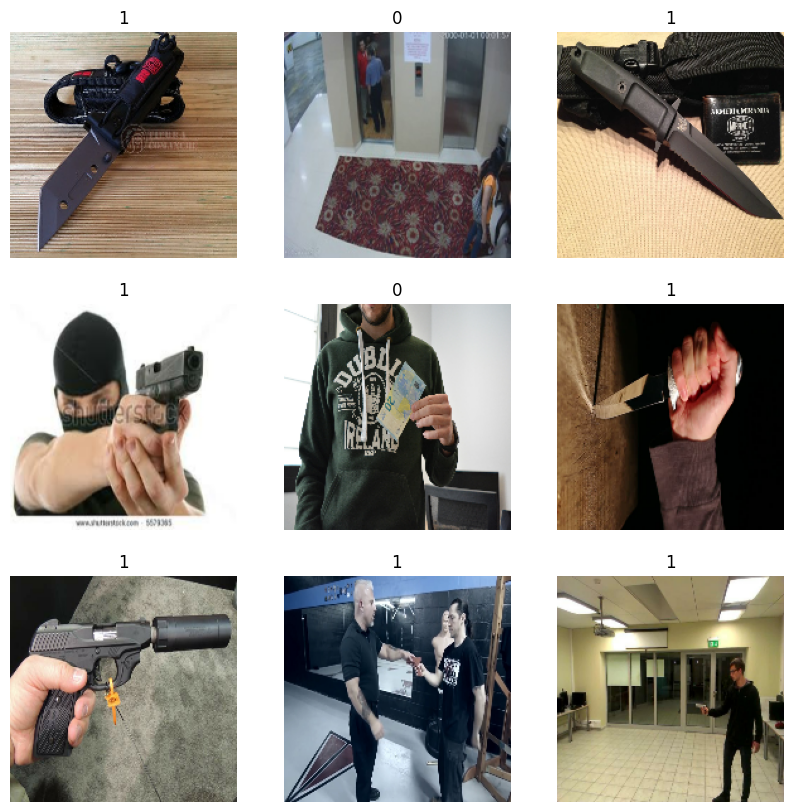

In [21]:
HARIS_train_images = "data/HARIS_classification_train/"
HARIS_val_images = "data/HARIS_classification_validation/"

image_size = (180, 180)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    HARIS_train_images,
    # validation_split=0.2,
    # subset="training",
    # seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

val_ds = keras.utils.image_dataset_from_directory(
    HARIS_val_images,
    # validation_split=0.2,
    # subset="validation",
    # seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

print(f"Classes: {train_ds.class_names}")

In [22]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]


def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

In [23]:
# Apply `data_augmentation` to the training images.
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE,
)

# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))